<a href="https://colab.research.google.com/github/dineshsharma143/AI-Invoice-Automation-week-4-Assignment/blob/main/Neural_Network_Classification_on_AI_Invoice_Automation_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam

In [135]:
df = pd.read_csv("/content/AI Invoice Automation Dataset.csv")

df.head()

,Invoice_ID,Invoice_Date,Vendor_Name,Invoice_Number,Category,Description,Amount_USD,Tax_USD,Total_USD,Payment_Method,Due_Date,Status
0,INV00001,2026-03-09,City Electricity,NO1002,Utilities,Electricity Bill,594.96,59.50,654.46,Credit Card,2026-03-24,Overdue
1,INV00002,2026-05-27,Nepal Telecom,NO1003,Internet,Internet,705.93,70.59,776.52,Bank Transfer,2026-06-11,Paid
2,INV00003,2026-06-26,Cleaning Services,NO1004,Maintenance,Cleaning,696.14,69.61,765.75,Bank Transfer,2026-07-11,Paid
3,INV00004,2026-02-04,Cleaning Services,NO1005,Maintenance,Cleaning,281.51,28.15,309.66,Cash,2026-02-19,Pending
4,INV00005,2026-03-12,City Electricity,NO1006,Utilities,Electricity Bill,787.20,78.72,865.92,Credit Card,2026-03-27,Paid


In [136]:
df = df.drop(
    columns=[
        "Invoice_ID",
        "Invoice_Number",
        "Invoice_Date",
        "Due_Date"
    ],
    errors="ignore"
)

In [137]:
X = df.drop(
    "Status",
    axis=1
)

y = df["Status"]

In [138]:
encoder = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = encoder.fit_transform(X[col])

In [139]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['Overdue' 'Paid' 'Pending']


In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [141]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [142]:
dnn_model = Sequential()


dnn_model.add(
    Dense(
        128,
        activation="relu",
        input_shape=(X_train.shape[1],)
    )
)


dnn_model.add(
    Dense(
        64,
        activation="relu"
    )
)


dnn_model.add(
    Dropout(
        0.3
    )
)


dnn_model.add(
    Dense(
        32,
        activation="relu"
    )
)


dnn_model.add(
    Dense(
        3,
        activation="softmax"
    )
)


dnn_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


dnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,459 (44.76 KB)

 Trainable params: 11,459 (44.76 KB)

 Non-trainable params: 0 (0.00 B)

In [143]:
dnn_history = dnn_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.3469 - loss: 1.1049 - val_accuracy: 0.3000 - val_loss: 1.1031
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3469 - loss: 1.0993 - val_accuracy: 0.2875 - val_loss: 1.1067
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3812 - loss: 1.0877 - val_accuracy: 0.3625 - val_loss: 1.1048
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4156 - loss: 1.0889 - val_accuracy: 0.3750 - val_loss: 1.1029
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3938 - loss: 1.0721 - val_accuracy: 0.4000 - val_loss: 1.1033
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4531 - loss: 1.0683 - val_accuracy: 0.3375 - val_loss: 1.1059
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4281 - loss: 1.0647 - val_accuracy: 0.3375 - val_loss: 1.1087
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4531 - loss: 1.0484 - val_accuracy: 0.

In [144]:
dnn_probability = dnn_model.predict(
    X_test
)


dnn_prediction = np.argmax(
    dnn_probability,
    axis=1
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [145]:
X_train_cnn = np.expand_dims(
    X_train,
    axis=2
)


X_test_cnn = np.expand_dims(
    X_test,
    axis=2
)


print(X_train_cnn.shape)

(400, 7, 1)


In [146]:
cnn_model = Sequential()


cnn_model.add(
    Conv1D(
        filters=64,
        kernel_size=2,
        activation="relu",
        input_shape=(
            X_train_cnn.shape[1],
            1
        )
    )
)


cnn_model.add(
    MaxPooling1D(
        pool_size=2
    )
)


cnn_model.add(
    Flatten()
)


cnn_model.add(
    Dense(
        64,
        activation="relu"
    )
)


cnn_model.add(
    Dropout(
        0.3
    )
)


cnn_model.add(
    Dense(
        3,
        activation="softmax"
    )
)



cnn_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 6, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,739 (49.76 KB)

 Trainable params: 12,739 (49.76 KB)

 Non-trainable params: 0 (0.00 B)

In [147]:
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.3156 - loss: 1.1173 - val_accuracy: 0.3625 - val_loss: 1.1011
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3906 - loss: 1.0936 - val_accuracy: 0.3375 - val_loss: 1.1060
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3875 - loss: 1.0967 - val_accuracy: 0.3125 - val_loss: 1.1077
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3625 - loss: 1.0876 - val_accuracy: 0.3125 - val_loss: 1.1013
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4250 - loss: 1.0844 - val_accuracy: 0.3125 - val_loss: 1.0961
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4219 - loss: 1.0791 - val_accuracy: 0.3375 - val_loss: 1.0978
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4375 - loss: 1.0803 - val_accuracy: 0.3000 - val_loss: 1.1016
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4062 - loss: 1.0755 - val_accuracy: 0.2875

In [148]:
cnn_probability = cnn_model.predict(
    X_test_cnn
)


cnn_prediction = np.argmax(
    cnn_probability,
    axis=1
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [149]:
dnn_accuracy = accuracy_score(
    y_test,
    dnn_prediction
)


cnn_accuracy = accuracy_score(
    y_test,
    cnn_prediction
)



comparison = pd.DataFrame(
    {
        "Model":[
            "DNN",
            "CNN"
        ],

        "Accuracy":[
            dnn_accuracy,
            cnn_accuracy
        ]
    }
)


comparison

,Model,Accuracy
0,DNN,0.31
1,CNN,0.26


In [150]:
print(
    classification_report(
        y_test,
        dnn_prediction,
        target_names=target_encoder.classes_
    )
)

              precision    recall  f1-score   support

     Overdue       0.33      0.30      0.32        33
        Paid       0.27      0.32      0.29        37
     Pending       0.36      0.30      0.33        30

    accuracy                           0.31       100
   macro avg       0.32      0.31      0.31       100
weighted avg       0.32      0.31      0.31       100



In [151]:
print(
    classification_report(
        y_test,
        cnn_prediction,
        target_names=target_encoder.classes_
    )
)

              precision    recall  f1-score   support

     Overdue       0.40      0.36      0.38        33
        Paid       0.21      0.24      0.23        37
     Pending       0.18      0.17      0.17        30

    accuracy                           0.26       100
   macro avg       0.26      0.26      0.26       100
weighted avg       0.26      0.26      0.26       100



In [152]:
precision = precision_score(
    y_test,
    cnn_prediction,
    average="weighted"
)


recall = recall_score(
    y_test,
    cnn_prediction,
    average="weighted"
)


f1 = f1_score(
    y_test,
    cnn_prediction,
    average="weighted"
)


print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

Precision: 0.2648571428571429
Recall: 0.26
F1 Score: 0.2617422211136746


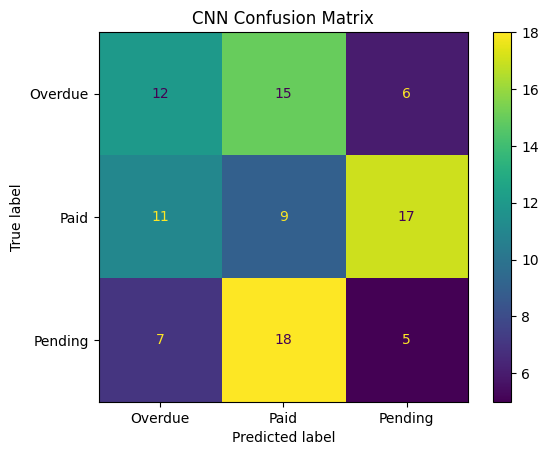

In [153]:
cm = confusion_matrix(
    y_test,
    cnn_prediction
)


display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)


display.plot()

plt.title(
    "CNN Confusion Matrix"
)

plt.show()

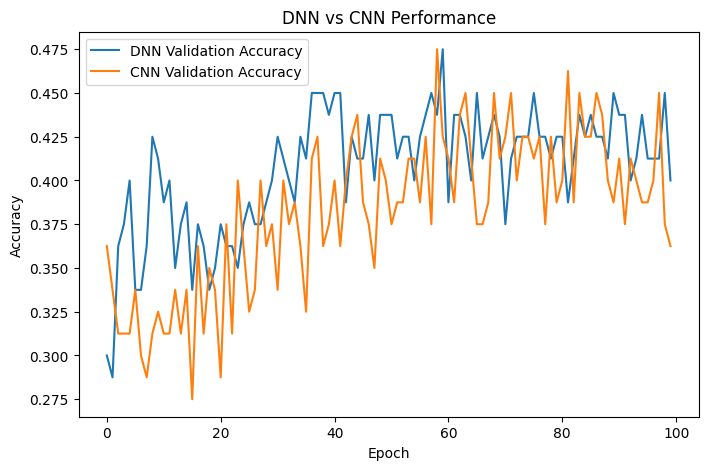

In [154]:
plt.figure(figsize=(8,5))


plt.plot(
    dnn_history.history["val_accuracy"],
    label="DNN Validation Accuracy"
)


plt.plot(
    cnn_history.history["val_accuracy"],
    label="CNN Validation Accuracy"
)


plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "DNN vs CNN Performance"
)


plt.legend()

plt.show()